# Supervised Learning — Transaction Categorization

**Owner:** Member A (Supervised Learning)

This notebook trains a model that predicts a **Category** for each transaction from
its text description (e.g. `SQ *BLUE BOTTLE COFFEE` → `Dining`).

Pipeline: **Load → Preprocess → TF-IDF → Train & compare classifiers → Evaluate →
Handle class imbalance → Test generalization → Export model.**

> Preprocessing and data loading are imported from `src/` so the notebook and the
> production app (`app.py`) use the *exact same* logic.


In [1]:
import sys
from pathlib import Path

# Robust project-root detection (works whether run from repo root or notebooks/)
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "inputs" / "synthetic_chase_statement_2025.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 40)
print("Project root:", PROJECT_ROOT)
print("Data file exists:", DATA_FILE.exists())


Project root: /Users/yinfeilu/Desktop/CS6140_Machine_Learning/FinalProject
Data file exists: True


## Step 1 — Load & preprocess

We reuse `src/data_loader.py` and `src/preprocessing.py`. The output is a clean
DataFrame with `Date, Description, Merchant, Amount, Category`.


In [2]:
from src.pipeline.data_loader import load_transactions_csv
from src.pipeline.preprocessing import preprocess_transactions

raw = load_transactions_csv(DATA_FILE)
df = preprocess_transactions(raw)
print("Rows:", len(df))
df.head()


Rows: 2304


,Date,Description,Merchant,Amount,Category
0,2025-01-01,NYTIMES DIGITAL LLC,NYTIMES DIGITAL LLC,-16.44,Subscription
1,2025-01-01,H AND M LLC,H AND M LLC,-125.85,Shopping
2,2025-01-01,PAYPAL *REI OUTDOOR,PAYPAL REI OUTDOOR,-22.48,Shopping
3,2025-01-01,GRUBHUB,GRUBHUB,-10.11,Dining
4,2025-01-01,IKEA HOME,IKEA HOME,-79.52,Shopping


## Step 2 — Exploratory analysis: class distribution

Categorization is a **multi-class, imbalanced** problem. Below, `Dining` dominates
while `Housing` has only a handful of rows. Imbalance is why we later report
**macro-F1** (treats every class equally) and not just accuracy.


Category
Dining           700
Shopping         414
Grocery          354
Transport        250
Entertainment    170
Subscription     134
Transfer          95
Healthcare        60
Utilities         60
Travel            55
Housing           12
Name: count, dtype: int64


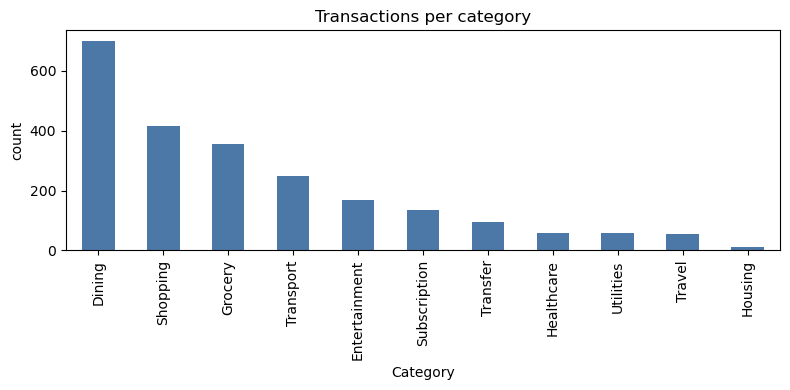

In [3]:
counts = df["Category"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Transactions per category")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


## Step 3 — Train / test split

We use the **text description** as input `X` and `Category` as label `y`.
`stratify=y` keeps each class's proportion identical in train and test — important
for imbalanced data.


In [4]:
from sklearn.model_selection import train_test_split

X = df["Description"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train), " Test:", len(X_test))


Train: 1843  Test: 461


## Step 4 — TF-IDF + model comparison

**TF-IDF** converts each description into a numeric vector: words that are frequent
in a transaction but rare across the corpus (e.g. `COFFEE`, `PHARMACY`) get high
weight. `ngram_range=(1, 2)` also captures two-word phrases like `WHOLE FOODS`.

We compare three classic text classifiers taught in the course.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

def make_pipeline(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", clf),
    ])

candidates = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

rows = []
for name, clf in candidates.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 3),
        "macro_f1": round(f1_score(y_test, pred, average="macro"), 3),
    })

results = pd.DataFrame(rows).set_index("model")
results


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


,accuracy,macro_f1
model,,
Naive Bayes,0.978,0.968
Logistic Regression,0.978,0.964
Linear SVM,0.993,0.995


## Step 5 — Evaluate the best model

We look at the strongest model with a **per-class report** and a **confusion matrix**.
The confusion matrix shows *which* categories get confused with each other (e.g.
`Grocery` vs `Shopping` for warehouse stores like Costco).


               precision    recall  f1-score   support

       Dining       1.00      1.00      1.00       140
Entertainment       1.00      1.00      1.00        34
      Grocery       1.00      0.97      0.99        71
   Healthcare       1.00      1.00      1.00        12
      Housing       1.00      1.00      1.00         2
     Shopping       0.97      1.00      0.98        83
 Subscription       1.00      0.96      0.98        27
     Transfer       1.00      1.00      1.00        19
    Transport       1.00      1.00      1.00        50
       Travel       1.00      1.00      1.00        11
    Utilities       1.00      1.00      1.00        12

     accuracy                           0.99       461
    macro avg       1.00      0.99      1.00       461
 weighted avg       0.99      0.99      0.99       461



/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


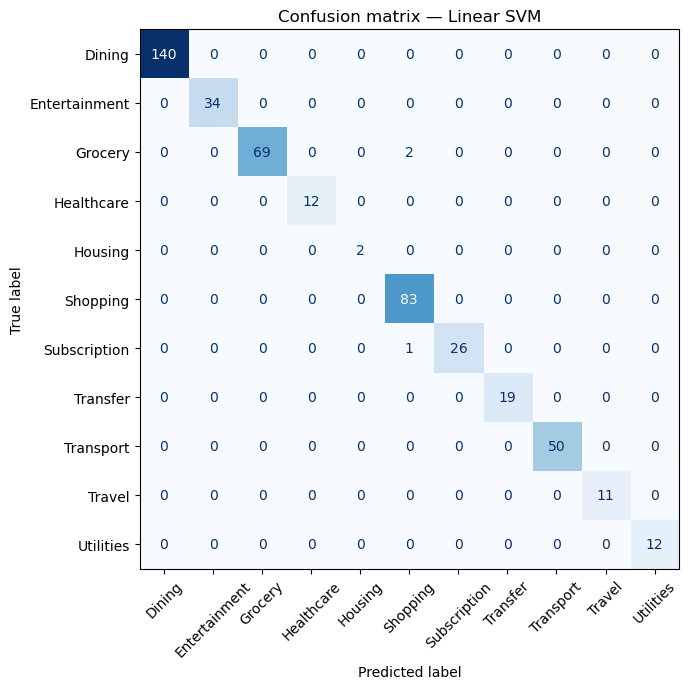

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best = make_pipeline(LinearSVC())
best.fit(X_train, y_train)
pred = best.predict(X_test)

print(classification_report(y_test, pred))

labels = sorted(y.unique())
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=labels, xticks_rotation=45,
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Confusion matrix — Linear SVM")
plt.tight_layout()
plt.show()


## Step 6 — Handling class imbalance

Rare classes (`Housing`, `Travel`) have few examples, so the model sees them less.
`class_weight="balanced"` tells the model to *weight rare classes more heavily*.
We compare macro-F1 before vs after — macro-F1 is the right metric because it
averages per-class scores equally, so gains on rare classes show up.


In [7]:
def macro_f1_of(clf):
    p = make_pipeline(clf)
    p.fit(X_train, y_train)
    return round(f1_score(y_test, p.predict(X_test), average="macro"), 3)

comparison = pd.DataFrame({
    "default": {
        "Logistic Regression": macro_f1_of(LogisticRegression(max_iter=1000)),
        "Linear SVM": macro_f1_of(LinearSVC()),
    },
    "class_weight=balanced": {
        "Logistic Regression": macro_f1_of(LogisticRegression(max_iter=1000, class_weight="balanced")),
        "Linear SVM": macro_f1_of(LinearSVC(class_weight="balanced")),
    },
})
comparison


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


,default,class_weight=balanced
Logistic Regression,0.964,0.993
Linear SVM,0.995,0.995


## Step 7 — Generalization: can it categorize an *unseen* merchant?

A random split lets the *same* merchant appear in train and test, so the model can
"memorize". The real-world test is a **merchant-grouped split**: every merchant in
the test set is one the model has **never seen**. Success here means the model truly
learned from shared tokens (`COFFEE`, `MARKET`, ...) rather than memorizing brands.


In [8]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["Merchant"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr_idx, te_idx = next(gss.split(X, y, groups))

assert set(groups.iloc[tr_idx]).isdisjoint(set(groups.iloc[te_idx]))  # no overlap

pipe = make_pipeline(LinearSVC(class_weight="balanced"))
pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
pred_g = pipe.predict(X.iloc[te_idx])

print("Unseen-merchant accuracy :", round(accuracy_score(y.iloc[te_idx], pred_g), 3))
print("Unseen-merchant macro-F1 :", round(f1_score(y.iloc[te_idx], pred_g, average="macro"), 3))
print(f"\nTrain merchants: {groups.iloc[tr_idx].nunique()} | "
      f"Test merchants: {groups.iloc[te_idx].nunique()} | overlap: 0")


Unseen-merchant accuracy : 0.771
Unseen-merchant macro-F1 : 0.851

Train merchants: 840 | Test merchants: 360 | overlap: 0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


## Step 8 — Train final model on all data & export

For the production model we refit on the **full** dataset (train + test) so it uses
every available example, then save it as `models/category_model.pkl`. The app loads
this file and never retrains.


In [9]:
import joblib
import json

final_model = make_pipeline(LinearSVC(class_weight="balanced"))
final_model.fit(X, y)

model_path = MODELS_DIR / "category_model.pkl"
joblib.dump(final_model, model_path)

# Record the categories the model can output (useful for the app / downstream).
meta = {
    "categories": sorted(y.unique().tolist()),
    "n_training_rows": int(len(df)),
    "vectorizer": "tfidf(1,2), min_df=2",
    "classifier": "LinearSVC(class_weight=balanced)",
}
with open(MODELS_DIR / "category_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", model_path)
print("Sanity check:", final_model.predict(["SQ *PHILZ COFFEE PALO ALTO CA",
                                            "CHEVRON GAS #4471",
                                            "NETFLIX.COM"]))


Saved: /Users/yinfeilu/Desktop/CS6140_Machine_Learning/FinalProject/models/category_model.pkl
Sanity check: ['Dining' 'Transport' 'Subscription']


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


---

# Part 2 — Unsupervised Learning: Weekly Spending Patterns

**Owner:** Member B (Unsupervised Learning)

The classifier above tells us *what* each transaction is. This second stage asks a
different question: **what does a typical week of spending look like, and are there
recurring "types" of weeks?** We aggregate the categorized transactions into one
feature vector per week, then use **KMeans** to discover spending-pattern clusters.

Pipeline: **Weekly feature engineering → StandardScaler → choose K (elbow +
silhouette) → fit KMeans → name & interpret clusters → export models.**

> Feature engineering lives in `src/weekly_features.py`, so the notebook and the
> production app build week vectors identically.


## Step 9 — Weekly feature engineering

We reuse the labelled `df` from Part 1 (it already has a `Category` column) and
turn it into weekly vectors. Each week becomes 7 numbers:

- **4 composition ratios** — the share of the week's spend on Dining / Grocery /
  Shopping / Transport (the "占比" features).
- **3 magnitude features** — total spend, transaction count, average transaction.

Ratios describe *how* money is split; magnitude describes *how much*. Together
they separate, say, a cheap dining-heavy week from an expensive shopping week.


In [10]:
from src.ml.weekly_features import build_weekly_features, FEATURE_COLUMNS, feature_matrix

weekly = build_weekly_features(df)
print("Weeks:", len(weekly))
print("Features:", FEATURE_COLUMNS)
weekly.head()


Weeks: 53
Features: ['dining_ratio', 'grocery_ratio', 'shopping_ratio', 'transport_ratio', 'total_spend', 'txn_count', 'avg_txn']


,Week,dining_ratio,grocery_ratio,shopping_ratio,transport_ratio,total_spend,txn_count,avg_txn
0,2024-12-30,0.032530,0.151753,0.134056,0.022450,5789.69,43,134.643953
1,2025-01-06,0.055308,0.095263,0.205708,0.032682,4536.38,40,113.409500
2,2025-01-13,0.065698,0.025699,0.580574,0.027408,5892.87,40,147.321750
3,2025-01-20,0.137598,0.227247,0.487497,0.025318,4136.99,44,94.022500
4,2025-01-27,0.082710,0.235352,0.286213,0.036837,3526.88,40,88.172000


## Step 10 — Standardize the features

KMeans uses Euclidean distance, and our features live on wildly different scales:
ratios are in `[0, 1]` while `total_spend` runs into the thousands. Without
scaling, `total_spend` alone would dominate every distance and the ratios would be
ignored. `StandardScaler` puts every feature on a mean-0 / unit-variance footing so
each contributes fairly. The fitted scaler is exported and reused at inference.


In [11]:
from sklearn.preprocessing import StandardScaler

X = feature_matrix(weekly)
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
print("Scaled matrix shape:", X_scaled.shape)
print("Per-feature mean after scaling (~0):", X_scaled.mean(axis=0).round(2))


Scaled matrix shape: (53, 7)
Per-feature mean after scaling (~0): [-0.  0.  0.  0.  0. -0. -0.]


## Step 11 — Choose K (elbow method + silhouette score)

KMeans needs the number of clusters `K` up front. We sweep `K = 2..8` and look at
two diagnostics:

- **Inertia (elbow method)** — within-cluster sum of squares. It always drops as K
  grows; we look for the "elbow" where extra clusters stop helping much.
- **Silhouette score** — how well-separated the clusters are (higher is better,
  range −1..1).

The elbow sits around **K = 3–4** (inertia flattens after 4), and silhouette is
comparable across that range. We adopt **K = 4** because it yields four clearly
interpretable, actionable spending patterns that map onto the product's design,
while keeping cluster separation reasonable.


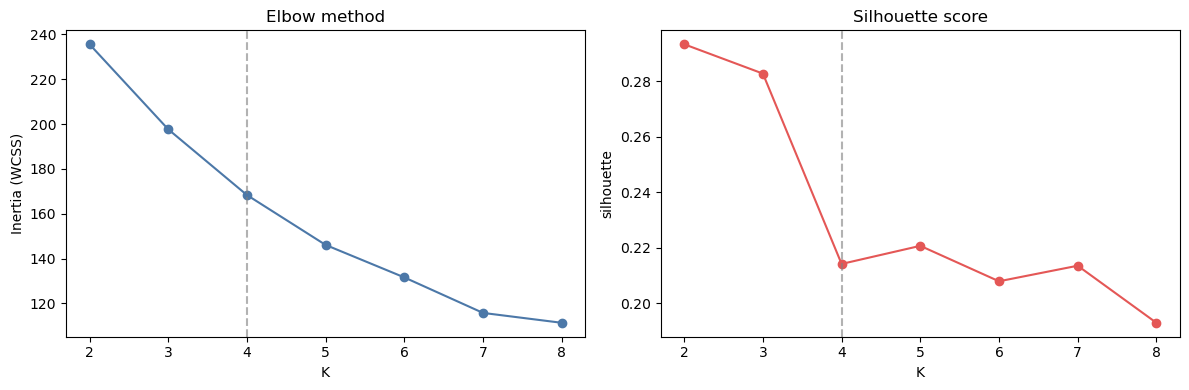

K=2  inertia=  235.59  silhouette=0.293
K=3  inertia=  197.68  silhouette=0.283
K=4  inertia=  168.37  silhouette=0.214
K=5  inertia=  146.12  silhouette=0.221
K=6  inertia=  131.63  silhouette=0.208
K=7  inertia=  115.80  silhouette=0.213
K=8  inertia=  111.40  silhouette=0.193


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 9)
inertias, silhouettes = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(Ks), inertias, "o-", color="#4C78A8")
ax1.set(title="Elbow method", xlabel="K", ylabel="Inertia (WCSS)")
ax1.axvline(4, ls="--", color="grey", alpha=0.6)
ax2.plot(list(Ks), silhouettes, "o-", color="#E45756")
ax2.set(title="Silhouette score", xlabel="K", ylabel="silhouette")
ax2.axvline(4, ls="--", color="grey", alpha=0.6)
plt.tight_layout(); plt.show()

for k, inr, sil in zip(Ks, inertias, silhouettes):
    print(f"K={k}  inertia={inr:8.2f}  silhouette={sil:.3f}")


## Step 12 — Fit the final KMeans model (K = 4)


In [13]:
K = 4
model = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
weekly["Cluster"] = model.labels_
print(f"Final model: KMeans(K={K})  silhouette={silhouette_score(X_scaled, model.labels_):.3f}")
print("Weeks per cluster:")
print(weekly["Cluster"].value_counts().sort_index())


Final model: KMeans(K=4)  silhouette=0.214
Weeks per cluster:
Cluster
0    10
1    20
2    15
3     8
Name: count, dtype: int64


## Step 13 — Interpret & name the clusters

A cluster id (`0, 1, 2, 3`) means nothing to a user. We read each cluster's
**centroid** to give it a human name. Because centroids live in standardized space,
each coordinate is a **z-score** — how far that cluster sits from the average week
on that feature. We name a cluster after its most distinctive (highest-z) feature.

One refinement: features like `transport_ratio` have tiny variance, so a small
absolute lift can produce a large z-score. When two composition ratios are nearly
tied on z, we prefer the one that is the larger actual **share of spend** — so a
week that is 14% dining / 6% transport reads as *Dining-heavy*, matching intuition.


In [14]:
import numpy as np

FEATURE_LABELS = {
    "dining_ratio": "Dining-heavy", "grocery_ratio": "Grocery-focused",
    "shopping_ratio": "Shopping-heavy", "transport_ratio": "Transport-heavy",
    "total_spend": "High-Spending", "txn_count": "High-Frequency",
    "avg_txn": "Big-Ticket",
}
RATIO_FEATURES = {"dining_ratio", "grocery_ratio", "shopping_ratio", "transport_ratio"}
BALANCED_THRESHOLD, TIE_MARGIN = 0.5, 0.4

mean_ratios = weekly.groupby("Cluster")[FEATURE_COLUMNS].mean()

def name_cluster(cid, z):
    order = list(np.argsort(z)[::-1])
    top, second = order[0], order[1]
    tf, sf = FEATURE_COLUMNS[top], FEATURE_COLUMNS[second]
    if z[top] < BALANCED_THRESHOLD:
        return "Balanced"
    chosen = tf
    if (z[top] - z[second] < TIE_MARGIN and tf in RATIO_FEATURES and sf in RATIO_FEATURES
            and mean_ratios.loc[cid, sf] > mean_ratios.loc[cid, tf]):
        chosen = sf
    return FEATURE_LABELS[chosen]

cluster_names = {int(c): name_cluster(c, z) for c, z in enumerate(model.cluster_centers_)}
weekly["PatternName"] = weekly["Cluster"].map(cluster_names)
print("Cluster names:", cluster_names)


Cluster names: {0: 'Dining-heavy', 1: 'High-Spending', 2: 'Grocery-focused', 3: 'Shopping-heavy'}


### Cluster profile table

Centroids back in **original units** — this is the interpretable summary of each
discovered spending pattern (what goes into the paper).


In [15]:
profile = weekly.groupby("PatternName")[FEATURE_COLUMNS].mean()
profile["weeks"] = weekly.groupby("PatternName").size()
profile.round(3)


,dining_ratio,grocery_ratio,shopping_ratio,transport_ratio,total_spend,txn_count,avg_txn,weeks
PatternName,,,,,,,,
Dining-heavy,0.139,0.120,0.292,0.064,3099.357,39.900,76.941,10
Grocery-focused,0.100,0.223,0.344,0.025,3302.093,38.200,85.397,15
High-Spending,0.050,0.088,0.168,0.030,6630.159,48.450,137.503,20
Shopping-heavy,0.064,0.078,0.419,0.022,5229.178,40.375,130.342,8


### Visualizing the clusters

Left: a heatmap of the standardized centroids makes each pattern's "signature"
obvious (bright = above-average on that feature). Right: how many weeks fall into
each pattern.


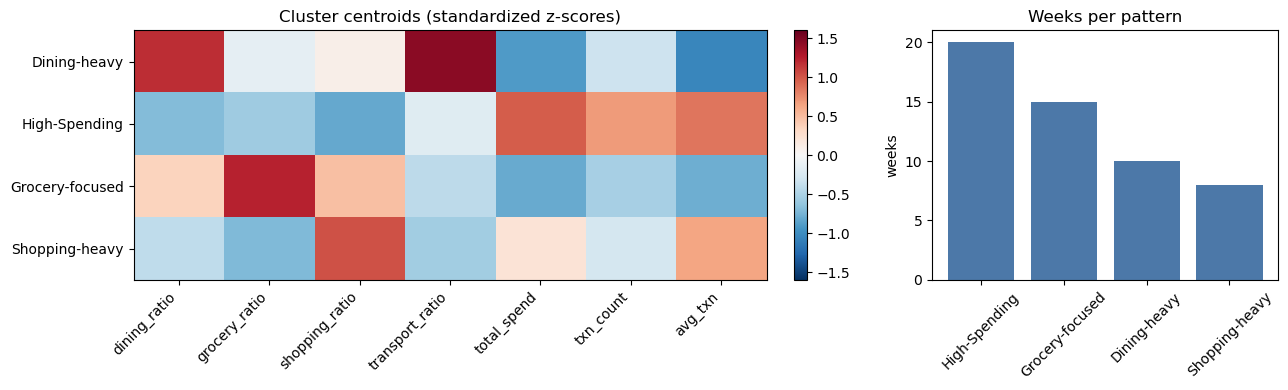

In [16]:
fig, (axh, axb) = plt.subplots(1, 2, figsize=(13, 4),
                               gridspec_kw={"width_ratios": [2, 1]})

centers_df = pd.DataFrame(model.cluster_centers_, columns=FEATURE_COLUMNS)
centers_df.index = [cluster_names[i] for i in centers_df.index]
im = axh.imshow(centers_df.values, cmap="RdBu_r", vmin=-1.6, vmax=1.6, aspect="auto")
axh.set_xticks(range(len(FEATURE_COLUMNS)))
axh.set_xticklabels(FEATURE_COLUMNS, rotation=45, ha="right")
axh.set_yticks(range(len(centers_df))); axh.set_yticklabels(centers_df.index)
axh.set_title("Cluster centroids (standardized z-scores)")
fig.colorbar(im, ax=axh, fraction=0.046, pad=0.04)

sizes = weekly["PatternName"].value_counts()
axb.bar(sizes.index, sizes.values, color="#4C78A8")
axb.set_title("Weeks per pattern"); axb.set_ylabel("weeks")
axb.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


### Spending patterns over time

Plotting weekly total spend coloured by pattern shows how the discovered types are
distributed across the year — useful for the dashboard's narrative.


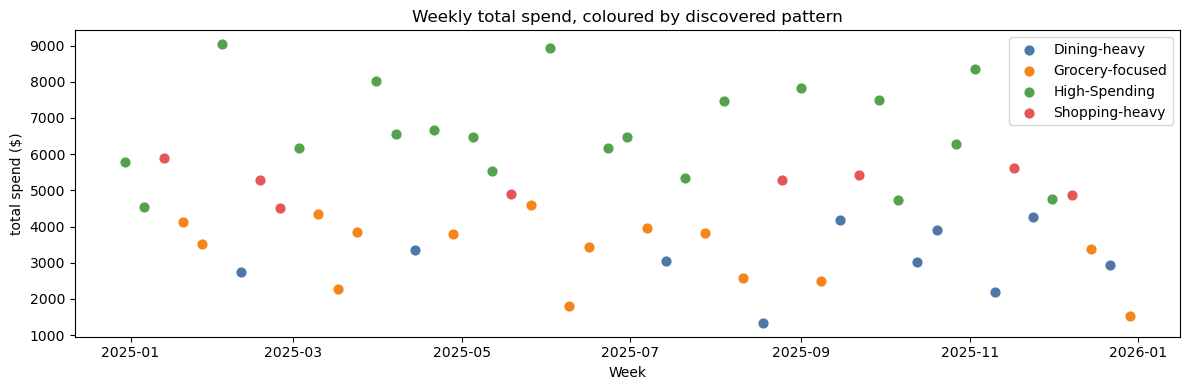

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
palette = {name: c for name, c in zip(sorted(cluster_names.values()),
           ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"])}
for name, g in weekly.groupby("PatternName"):
    ax.scatter(g["Week"], g["total_spend"], label=name, color=palette[name], s=40)
ax.set(title="Weekly total spend, coloured by discovered pattern",
       xlabel="Week", ylabel="total spend ($)")
ax.legend(); plt.tight_layout(); plt.show()


## Step 14 — Export models & config

We save four artifacts to `models/`. The production app loads these and never
retrains:

- `weekly_scaler.pkl` — the fitted StandardScaler
- `spending_pattern_model.pkl` — the fitted KMeans model
- `cluster_names.json` — cluster id → readable pattern name
- `feature_config.json` — the frozen feature ordering (inference must match)


In [18]:
import joblib, json
from src.ml.weekly_features import RATIO_CATEGORIES

joblib.dump(scaler, MODELS_DIR / "weekly_scaler.pkl")
joblib.dump(model, MODELS_DIR / "spending_pattern_model.pkl")

with open(MODELS_DIR / "cluster_names.json", "w") as f:
    json.dump({str(k): v for k, v in cluster_names.items()}, f, indent=2)

with open(MODELS_DIR / "feature_config.json", "w") as f:
    json.dump({
        "feature_columns": FEATURE_COLUMNS,
        "ratio_categories": RATIO_CATEGORIES,
        "n_clusters": K,
        "silhouette": round(float(silhouette_score(X_scaled, model.labels_)), 3),
        "scaler": "StandardScaler",
        "model": "KMeans",
        "n_training_weeks": int(len(weekly)),
    }, f, indent=2)

print("Saved: weekly_scaler.pkl, spending_pattern_model.pkl, "
      "cluster_names.json, feature_config.json")


Saved: weekly_scaler.pkl, spending_pattern_model.pkl, cluster_names.json, feature_config.json
